**Анализ оттока клиентов телеком-оператора**

# Telecom Customer Churn Analysis

## Цель проекта
Проанализировать отток клиентов телеком-оператора и выявить факторы, влияющие на churn.

## Основные задачи
• Очистка и подготовка данных  
• Исследовательский анализ (EDA)  
• Поиск факторов оттока клиентов  
• Формирование бизнес-выводов

In [25]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)

In [27]:
df = pd.read_csv("data/Telco-Customer-Churn.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [28]:
df.isna().sum()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

**Первичный анализ**

In [29]:
df.shape

(7032, 21)

В датасете содержится информация о клиентах телеком-оператора.
Посмотрим типы данных и пропуски.

In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [31]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Очистка данных**

In [32]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [33]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Были обнаружены пропуски в столбце TotalCharges.
После приведения типов и удаления пропусков данные готовы к анализу.

In [34]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [35]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
churn_rate

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

Доля клиентов, покинувших компанию, составляет ~26%.
Это высокий уровень оттока, требующий анализа причин.

**Визуализация churn**

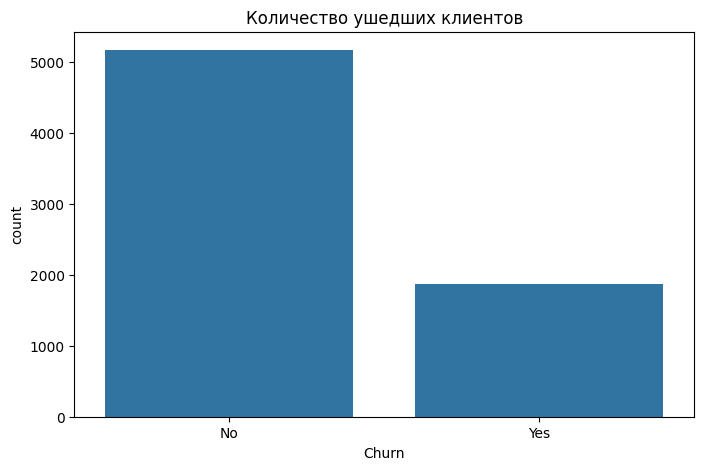

In [37]:
sns.countplot(x="Churn", data=df)
plt.title("Количество ушедших клиентов")
plt.show()

Количество клиентов, оставшихся в компании, значительно выше, однако доля ушедших клиентов существенна.

**Churn по типу контракта**

In [38]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


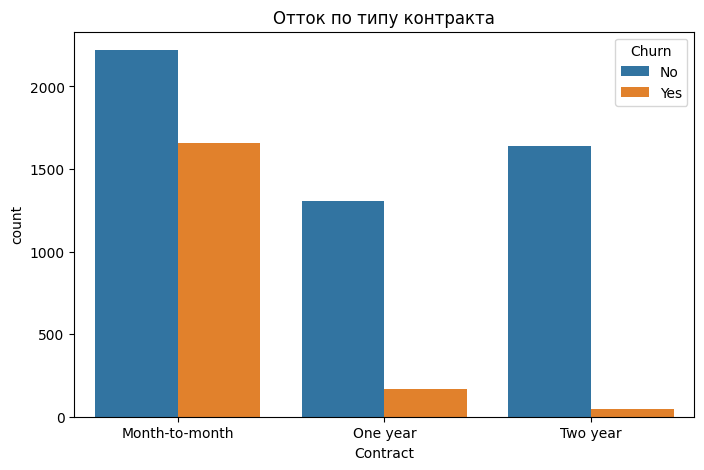

In [39]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Отток по типу контракта")
plt.show()

Клиенты с помесячным контрактом уходят значительно чаще.
Долгосрочные контракты снижают вероятность оттока.

**Churn по оплате**

In [40]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


Клиенты с электронными платежами чаще покидают компанию.
Возможно, данный сегмент более чувствителен к цене и качеству услуг.

**Churn по интернет-услугам**

In [41]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


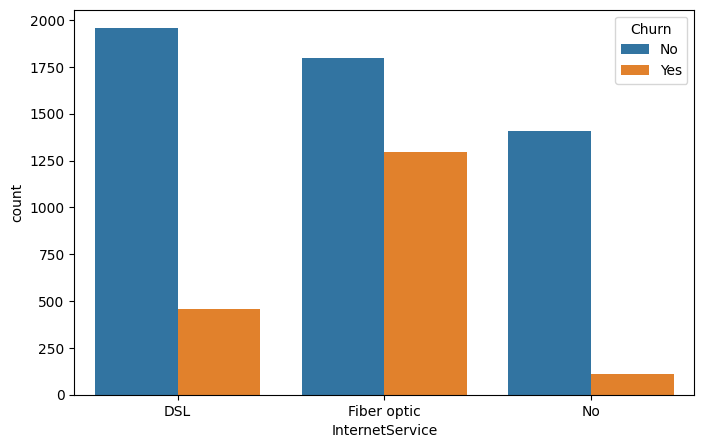

In [42]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

Клиенты с оптоволоконным интернетом уходят чаще.
Это может говорить о высокой конкуренции в данном сегменте.

**Финансовый анализ**

Средний доход.

In [43]:
df["MonthlyCharges"].mean()

np.float64(64.79820819112628)

In [44]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

Ушедшие клиенты платили в среднем больше.
Это указывает на риск потери наиболее прибыльных клиентов.

**Стаж клиентов**

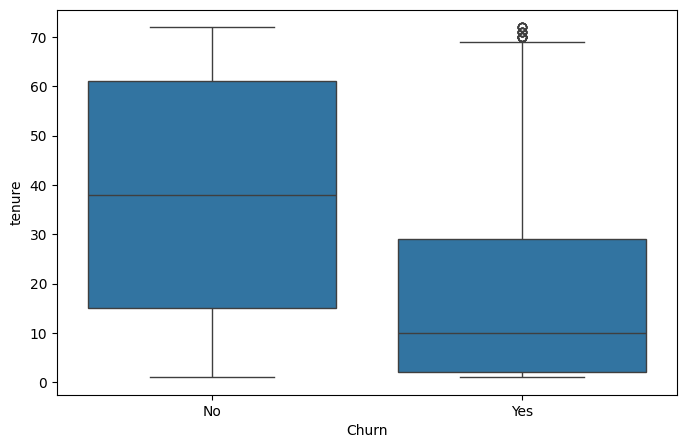

In [45]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

Новые клиенты уходят чаще.
Основной риск оттока приходится на первые месяцы использования.

**Выводы**

# Финальные бизнес-выводы

В ходе анализа были выявлены ключевые факторы оттока клиентов:

1. Тип контракта  
Клиенты с помесячным контрактом уходят значительно чаще.

2. Стаж клиента  
Основной отток происходит в первые месяцы использования.

3. Стоимость услуг  
Уходящие клиенты платят больше среднего → компания теряет прибыльный сегмент.

4. Интернет-услуги  
Высокий churn среди пользователей оптоволокна.

## Рекомендации бизнесу

• Стимулировать переход на долгосрочные контракты  
• Улучшить onboarding новых клиентов  
• Создать удерживающие предложения для дорогих тарифов  
• Провести дополнительный анализ качества интернет-услуг